In [3]:
import pandas as pd

# 1. Cargar el dataset
df = pd.read_csv('Iris.csv')

# 2. Transformar la columna 'Id' a un código de 3 dígitos (Zero-padded)
# Utilizamos el método nativo de pandas astype(str) seguido de str.zfill(3) 
# que rellena con ceros a la izquierda hasta completar 3 caracteres.
df['Id'] = df['Id'].astype(str).str.zfill(3)

# Alternativa equivalente usando f-strings (muy legible en Python moderno):
# df['Id'] = df['Id'].apply(lambda x: f"{x:03d}")

# 3. Validar el cambio de tipo de dato (debe pasar de int64 a object/string)
print("--- Tipo de dato actualizado ---")
print(f"Tipo de dato de la columna Id: {df['Id'].dtype}\n")

# 4. Visualizar los resultados (primeros y últimos registros)
print("--- Primeros 5 registros ---")
print(df[['Id', 'SepalLengthCm', 'Species']].head())

print("\n--- Últimos 5 registros ---")
print(df[['Id', 'SepalLengthCm', 'Species']].tail())

df.to_csv('Iris.csv', index=False, encoding='utf-8')

--- Tipo de dato actualizado ---
Tipo de dato de la columna Id: str

--- Primeros 5 registros ---
    Id  SepalLengthCm      Species
0  001            5.1  Iris-setosa
1  002            4.9  Iris-setosa
2  003            4.7  Iris-setosa
3  004            4.6  Iris-setosa
4  005            5.0  Iris-setosa

--- Últimos 5 registros ---
      Id  SepalLengthCm         Species
145  146            6.7  Iris-virginica
146  147            6.3  Iris-virginica
147  148            6.5  Iris-virginica
148  149            6.2  Iris-virginica
149  150            5.9  Iris-virginica


In [5]:
# 2. Aplicar el formato de 3 dígitos al Id (por si se ejecuta el script desde cero)
df['Id'] = df['Id'].astype(str).str.zfill(3)

# 3. Ingeniería de Features: Crear la columna SepalToPetalRatio
# Nota: En este dataset específico, PetalLengthCm nunca es 0 (mínimo es 1.0), 
# por lo que la división es segura. En otros contextos, se usaría np.where o fillna para evitar divisiones por cero.
df['SepalToPetalRatio'] = df['SepalLengthCm'] / df['PetalLengthCm']

# 4. Validar el resultado visualizando las primeras filas
print("--- Muestra de los datos con la nueva variable ---")
cols_to_show = ['Id', 'SepalLengthCm', 'PetalLengthCm', 'SepalToPetalRatio', 'Species']
print(df[cols_to_show].head(10))

# 5. Insight inmediato: Estadísticas descriptivas del nuevo ratio agrupado por especie
print("\n--- Estadísticas del Ratio Sépalo/Pétalo por Especie ---")
ratio_stats = df.groupby('Species')['SepalToPetalRatio'].describe().round(2)
print(ratio_stats)

df.to_csv('Iris.csv', index=False, encoding='utf-8')

--- Muestra de los datos con la nueva variable ---
    Id  SepalLengthCm  PetalLengthCm  SepalToPetalRatio      Species
0  001            5.1            1.4           3.642857  Iris-setosa
1  002            4.9            1.4           3.500000  Iris-setosa
2  003            4.7            1.3           3.615385  Iris-setosa
3  004            4.6            1.5           3.066667  Iris-setosa
4  005            5.0            1.4           3.571429  Iris-setosa
5  006            5.4            1.7           3.176471  Iris-setosa
6  007            4.6            1.4           3.285714  Iris-setosa
7  008            5.0            1.5           3.333333  Iris-setosa
8  009            4.4            1.4           3.142857  Iris-setosa
9  010            4.9            1.5           3.266667  Iris-setosa

--- Estadísticas del Ratio Sépalo/Pétalo por Especie ---
                 count  mean   std   min   25%   50%   75%   max
Species                                                         
Ir

In [7]:
# 2. Estandarizar el Id a 3 dígitos (como acordamos anteriormente)
df['Id'] = df['Id'].astype(str).str.zfill(3)

# 3. Calcular el ratio Sépalo/Pétalo
df['SepalToPetalRatio'] = df['SepalLengthCm'] / df['PetalLengthCm']

# 4. Estandarizar a exactamente 2 decimales
df['SepalToPetalRatio'] = df['SepalToPetalRatio'].round(2)

# 5. Validar el resultado
print("--- Muestra de datos con el Ratio redondeado a 2 decimales ---")
cols_to_show = ['Id', 'SepalLengthCm', 'PetalLengthCm', 'SepalToPetalRatio', 'Species']
print(df[cols_to_show].head(10))

# Opcional: Verificar que el tipo de dato se mantiene como numérico (float64)
print("\n--- Tipos de datos ---")
print(df[['SepalLengthCm', 'PetalLengthCm', 'SepalToPetalRatio']].dtypes)

df.to_csv('Iris.csv', index=False, encoding='utf-8')

--- Muestra de datos con el Ratio redondeado a 2 decimales ---
    Id  SepalLengthCm  PetalLengthCm  SepalToPetalRatio      Species
0  001            5.1            1.4               3.64  Iris-setosa
1  002            4.9            1.4               3.50  Iris-setosa
2  003            4.7            1.3               3.62  Iris-setosa
3  004            4.6            1.5               3.07  Iris-setosa
4  005            5.0            1.4               3.57  Iris-setosa
5  006            5.4            1.7               3.18  Iris-setosa
6  007            4.6            1.4               3.29  Iris-setosa
7  008            5.0            1.5               3.33  Iris-setosa
8  009            4.4            1.4               3.14  Iris-setosa
9  010            4.9            1.5               3.27  Iris-setosa

--- Tipos de datos ---
SepalLengthCm        float64
PetalLengthCm        float64
SepalToPetalRatio    float64
dtype: object


/tmp/ipykernel_10488/2350341832.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', ax=ax_cat, palette='Set2', edgecolor='black')


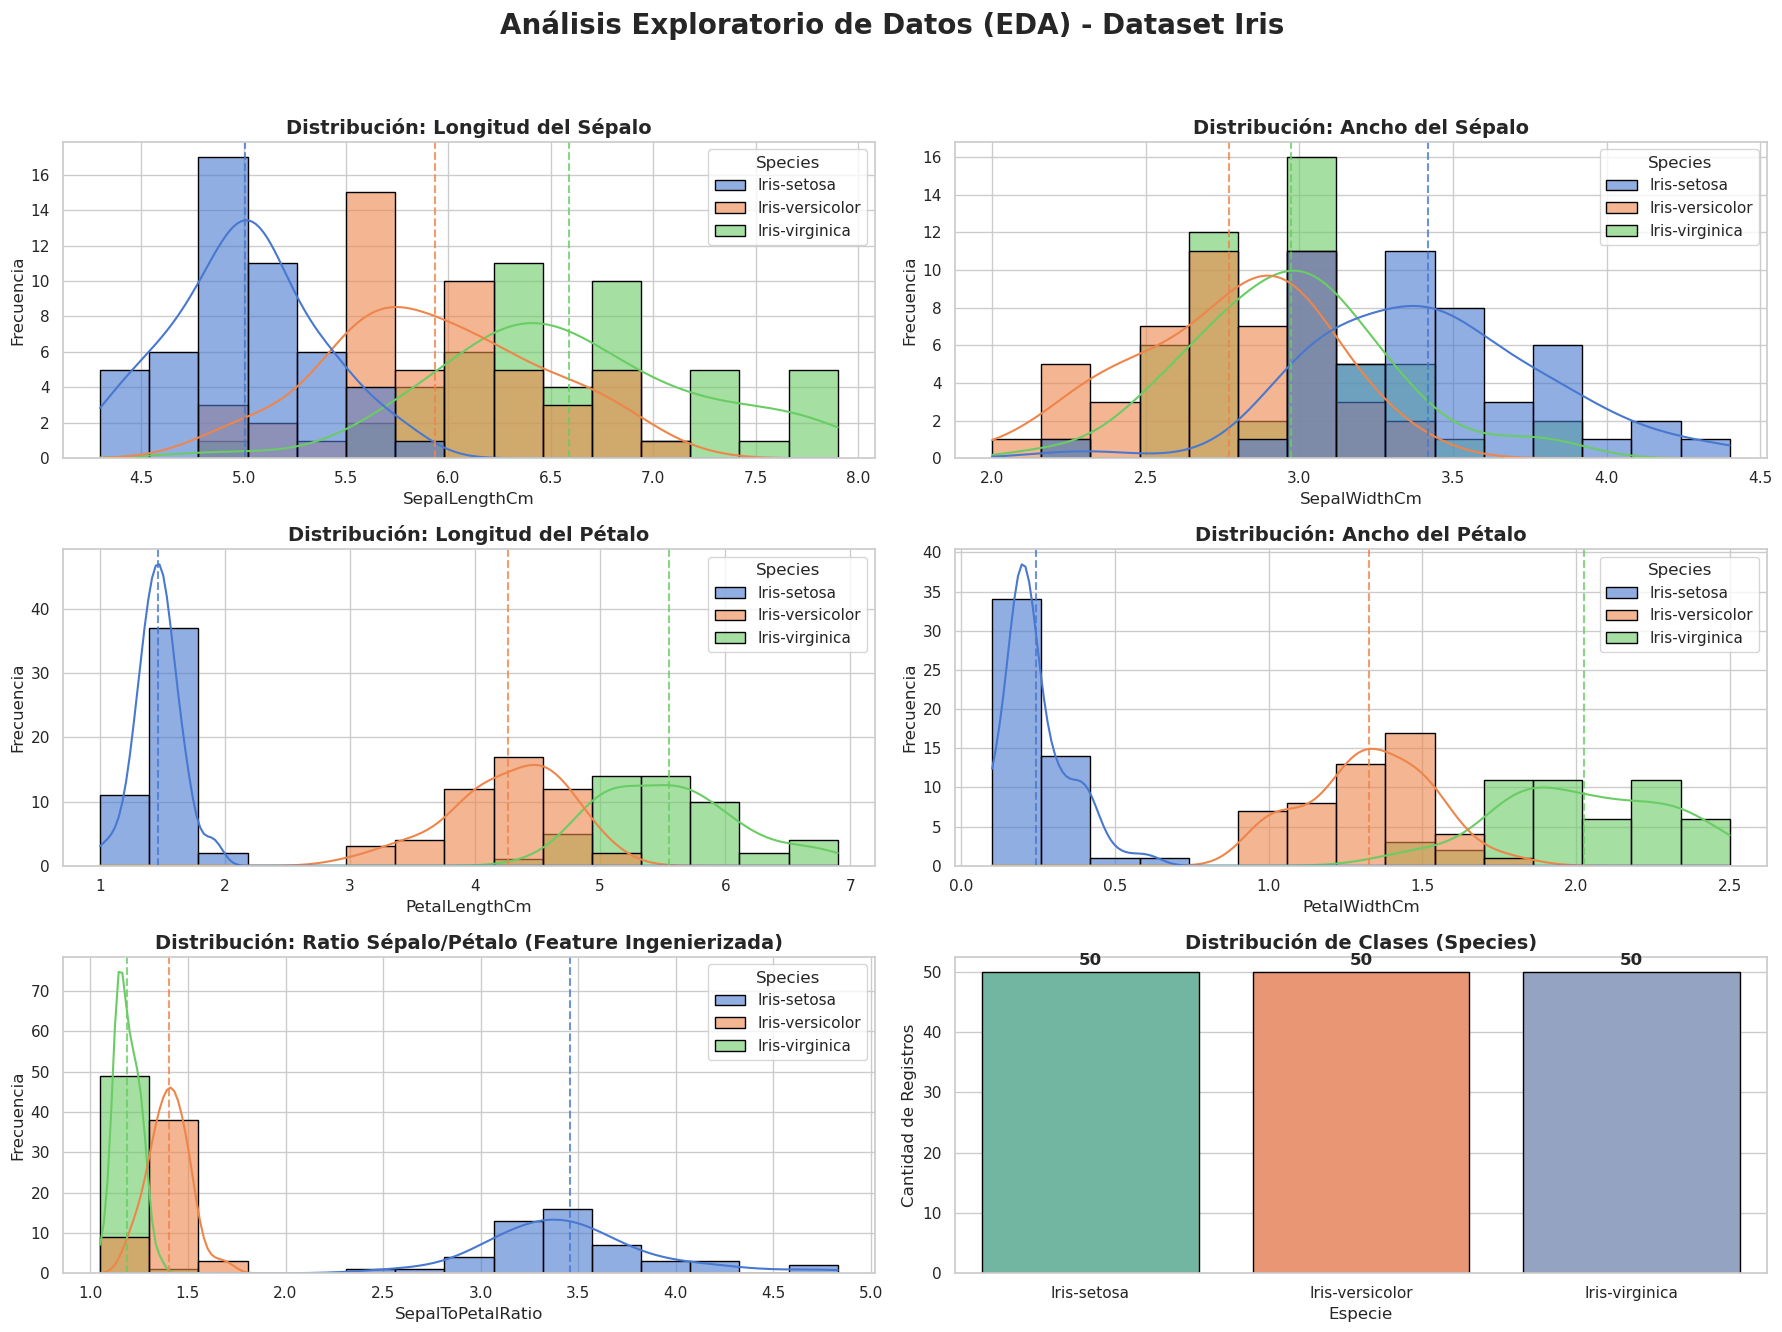

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración del estilo visual (Estándar corporativo limpio)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

# 2. Carga y preparación de datos (incluyendo nuestros pasos anteriores)
df = pd.read_csv('Iris.csv')
df['Id'] = df['Id'].astype(str).str.zfill(3)
df['SepalToPetalRatio'] = (df['SepalLengthCm'] / df['PetalLengthCm']).round(2)

# 3. Creación del Dashboard de Visualización (Grid de 3x2)
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Análisis Exploratorio de Datos (EDA) - Dataset Iris', fontsize=20, fontweight='bold', y=0.98)

# Lista de variables numéricas a analizar
numeric_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'SepalToPetalRatio']
titles = [
    'Distribución: Longitud del Sépalo',
    'Distribución: Ancho del Sépalo',
    'Distribución: Longitud del Pétalo',
    'Distribución: Ancho del Pétalo',
    'Distribución: Ratio Sépalo/Pétalo (Feature Ingenierizada)'
]

# 4. Generar gráficos de distribución (Histplot + KDE) por especie
for i, (feature, title) in enumerate(zip(numeric_features, titles)):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Histplot con KDE superpuesto, segmentado por especie
    sns.histplot(data=df, x=feature, hue='Species', kde=True, ax=ax, bins=15, alpha=0.6, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    
    # Añadir líneas de media por especie para referencia rápida
    means = df.groupby('Species')[feature].mean()
    for species, mean_val in means.items():
        ax.axvline(mean_val, color=sns.color_palette()[list(df['Species'].unique()).index(species)], 
                   linestyle='dashed', linewidth=1.5, alpha=0.8)

# 5. Gráfico de distribución para la variable categórica (Balance de clases)
ax_cat = axes[2, 1]
sns.countplot(data=df, x='Species', ax=ax_cat, palette='Set2', edgecolor='black')
ax_cat.set_title('Distribución de Clases (Species)', fontsize=14, fontweight='bold')
ax_cat.set_xlabel('Especie', fontsize=12)
ax_cat.set_ylabel('Cantidad de Registros', fontsize=12)

# Añadir etiquetas de valor sobre las barras
for p in ax_cat.patches:
    ax_cat.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=12, fontweight='bold', xytext=(0, 8), textcoords='offset points')

# 6. Ajuste final y visualización
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el espacio para el título principal
plt.show()